In [1]:
import numpy as np
from sklearn import linear_model
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('dark_background')

/home/pt202342/miniconda3/envs/id-diff/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:


from natsort import natsorted


# ALDI - new format

In [3]:
import numpy as np
from sklearn import linear_model
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from tqdm import tqdm

plt.style.use('dark_background')


In [11]:



# ALL_DELTAS = [0.00015625, 0.0003125, 0.000625,0.00125,0.0025,0.005,0.01,0.02,0.04,0.08,0.16,0.32,0.64,1.28]
# ALL_BACKBONES = ["maf", "rqnsf"]
# ALL_KNS = [3, 5, 9, 17, 33, 65, 129, 257]

# results = []

# ALL_DELTAS = [0.00015625, 0.0003125, 0.000625]
ALL_DELTAS = [0.0039, 0.0078, 0.0156, 0.0312, 0.0625, 0.1250, 0.2500, 0.5000, 1.0000]
# WARNING - KEEP THE RIGHT ORDER FROM SMALLEST TO BIGGEST!
ALL_DELTA_RUNS = ["0.0039;0.0078;0.0156;0.0312;0.0625;0.1250", "0.2500;0.5000;1.0000"]
ALL_BACKBONES = ["maf/widecoeff"]#["maf/coeff"] #, "maf/widecoeff"] #["maf/coeff"]#, "rqnsf"]

ALL_KNS = [
    "e8/gaussian4_pca", 
    "e8/spaghetti_pca", "e8/sphere4_pca", 
    # "e1/spiral_pca", 
    "e2/uniform_pca", 
    "e3/gaussian_pca",  
    "e6/exp_pca",
    "e7/crescent_moon_pca",
    
    # "e5/stretched_power4", 
    # "e5/stretched_power0.25",
    # "e4/sphere_pca_radius025", "e4/sphere_pca_radius050", "e4/sphere_pca_radius100", 
    # "e4/sphere_pca_radius200",
    # "e5/padded_fmnist_adddim0", "e5/padded_fmnist_adddim4", "e5/padded_fmnist_adddim8", 
    # "e5/upscaled_fmnist",
    # "e5/downscaled_fmnist",
    # "e1/sampled_fmnist_step1", "e1/sampled_fmnist_step2", "e1/sampled_fmnist_step3",
    # "e1/sampled_fmnist_step4", "e1/sampled_fmnist_step5", "e1/sampled_fmnist_step6",
    # "e1/sampled_fmnist_step7", "e1/sampled_fmnist_step8", "e1/sampled_fmnist_step9",
    # "e1/sampled_fmnist_step10", "e1/sampled_fmnist_step11", "e1/sampled_fmnist_step12", "e1/sampled_fmnist_step13",
    ]

results = []

def load_subset(path, backbone):
        # TODO CHANGE ME COEF/DATA
        if backbone in ["maf/widecoeff", "maf/coeff"]:
            train_data = np.load(path / "coefficients.npy") 
        else:
            train_data = np.load(path / "dataset.npy") 
            # 
        # train_lid = np.load(path / "lid.npy")
        # train_coefficients = np.load(path / "coefficients.npy")
        return (train_data.reshape(train_data.shape[0], -1), )


root_data_path = "/home/pt202342/projects/lid-benchmark-datasets/data/benchmarks_2024-12-09"
            
for backbone in ALL_BACKBONES:
    for k_n in  tqdm(ALL_KNS):
        # deltas_str = ';'.join([str(x) for x in ALL_DELTAS])
        # deltas_str = '0.0039;0.0078;0.0156;0.0312;0.0625;0.1250'

        k_n_test = k_n.replace("_pca", "_radius3.0") if k_n.startswith("e7") else k_n
        
        test_path = Path(root_data_path) / k_n_test.replace("/", "_") / "test"
        

        test_data = load_subset(test_path, backbone)

        lls_list = []
        for run in ALL_DELTA_RUNS:
            lls_list.append(torch.load(f"/home/pt202342/projects/lidl/results/{backbone}/{k_n}/{run}/lls.torch"))

        x = np.vstack(lls_list)
        
        for i in range(0, (len(ALL_DELTAS) - 2)):
            deltas = np.array(ALL_DELTAS[i: i+3])
            
            
            lls = x.transpose()[:, i: i+3]
            # total_dim = 2
            if backbone == 'maf/widecoeff':
                total_dim = 784
            else:
                total_dim = test_data[0].shape[1]

            dims = list()
            for i in range(lls.shape[0]):
                good_inds = ~np.logical_or(np.isnan(lls[i]), np.isinf(lls[i]))
                if ~good_inds.all():
                    print(
                        f"[WARNING] some log likelihoods are incorrect, deltas: {deltas}")
                ds = np.log(deltas[good_inds])
                ll = lls[i][good_inds]
                if ll.size < 2:
                    dims.append(np.nan)
                else:
                    regr = linear_model.LinearRegression()
                    regr.fit(ds.reshape(-1, 1), ll)
                    regr.predict(ds.reshape(-1, 1))
                    dims.append(total_dim - regr.coef_[0])
            results.append({
                "k_n": k_n,
                "avg_dim": np.mean(dims),
                "backbone": backbone,
                "deltas": str(deltas),
                "dims": np.array(dims)})

100%|██████████| 7/7 [00:17<00:00,  2.53s/it]


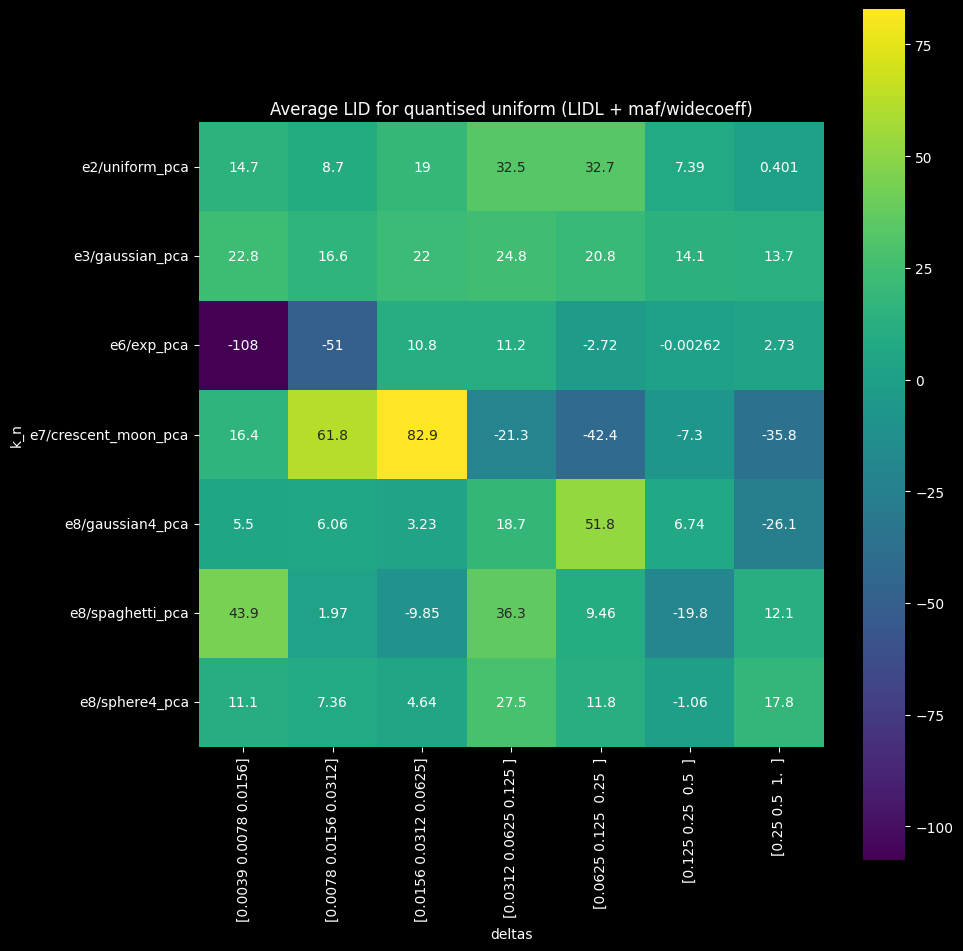

In [13]:
df = pd.DataFrame(results)
# df.to_json("aldi_lidl_results.json")
# df.to_csv("aldi_lidl_results.csv", index=False)
# df.to_parquet("aldi_lidl_results.parquet")
# df.to_parquet("aldi_lidl_results-coeff.parquet")
df.to_parquet("aldi_lidl_results-widecoeff.parquet")

def draw_heatmap(df, title):
    plt.figure(figsize=(10,10))
    piv = pd.pivot_table(df, values="avg_dim",index=["k_n"], columns=["deltas"], fill_value=0)
    piv = piv.reindex(natsorted(piv.index))
    ax = sns.heatmap(piv, square=True, cmap="viridis", annot=True,  fmt='.3g')
    # plt.ticklabel_format(style='plain')
    plt.setp( ax.xaxis.get_majorticklabels(), rotation=90 )
    plt.tight_layout()
    plt.title(title)
    plt.show()

for backbone in ALL_BACKBONES:
    # draw_heatmap(
    #     df[(df["backbone"] == backbone) & (df['k_n'].str.startswith('e1/sampled'))],
    #     f"Average LID for quantised uniform (LIDL + {backbone})"
    #     )
    
    draw_heatmap(
        df[(df["backbone"] == backbone) & ~(df['k_n'].str.startswith('e1/sampled'))],
        f"Average LID for quantised uniform (LIDL + {backbone})"
        )

In [12]:
%pip install natsort

4978.29s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached natsort-8.4.0-py3-none-any.whl.metadata (21 kB)
Using cached natsort-8.4.0-py3-none-any.whl (38 kB)
Note: you may need to restart the kernel to use updated packages.


In [10]:
from natsort import natsort_keygen, natsorted

df_ = pd.pivot_table(df, values="avg_dim",index=["k_n"], columns=["deltas"], fill_value=0)
df_.reset_index().to_csv("aldi_lidl_results_mean.csv", index=False)
df_
# .sort_index(
#     # by="time",
#     key=natsort_keygen()
# )

deltas,[0.0039 0.0078 0.0156],[0.0078 0.0156 0.0312],[0.0156 0.0312 0.0625],[0.0312 0.0625 0.125 ],[0.0625 0.125 0.25 ],[0.125 0.25 0.5 ],[0.25 0.5 1. ]
k_n,,,,,,,
e1/sampled_fmnist_step1,632.805736,575.773522,506.907867,430.805522,328.896134,218.823564,109.778656
e1/sampled_fmnist_step10,768.467133,760.473911,818.352975,842.993733,814.960525,552.306130,220.660166
e1/sampled_fmnist_step11,797.732580,775.849967,781.343330,805.748144,804.566116,658.689968,320.590241
e1/sampled_fmnist_step12,803.764669,786.910848,736.550277,770.571984,866.834919,820.588423,399.118761
e1/sampled_fmnist_step13,749.729374,779.201813,779.724918,802.366617,867.113781,891.911676,563.064263
e1/sampled_fmnist_step2,664.892668,589.507878,531.663322,465.322071,366.375097,241.780330,116.043870
e1/sampled_fmnist_step3,683.146638,645.128982,595.057443,509.801132,388.820836,266.038710,138.821256
e1/sampled_fmnist_step4,782.591969,689.157561,636.772035,590.144650,426.227600,298.372885,167.872154
e1/sampled_fmnist_step5,826.640433,783.151491,764.038553,697.457993,462.399172,322.700274,216.475741
